## Task 3.2: Failure Mode
* **Scenario Description**: A dataset where all three classes are determined strictly by thresholds on a *single* shared feature axis (Feature 0), with all other features being pure noise.
* **Why it struggles**: I expect the method to fail here because the core algorithm assumes child nodes need *different* features than their ancestors. By forcing the child vectors to be orthogonal to the parent vector, the model mathematically prevents the child from looking at Feature 0, forcing it to classify based on noise.

Hierarchical Model Accuracy on 1D Dataset: 49.00%
Flat Baseline Accuracy on 1D Dataset: 97.33%


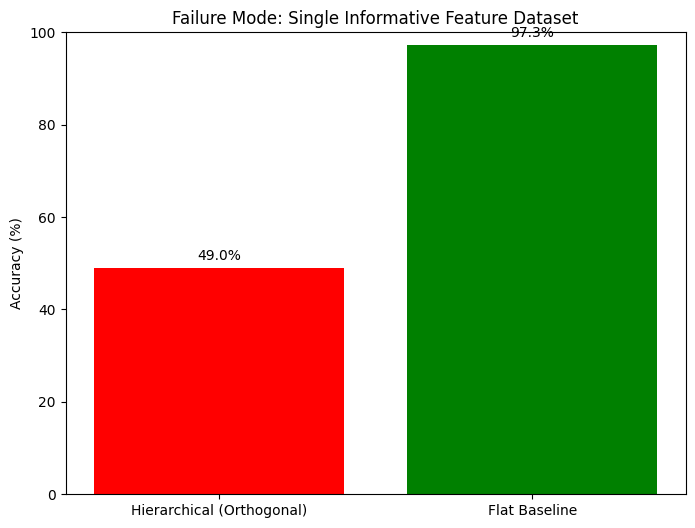

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("partB/results", exist_ok=True)

# ---------------------------------------------------------
# 1. Failure Mode Dataset (Strictly 1D dependence)
# ---------------------------------------------------------
# We generate a dataset where ONLY feature 0 matters.
np.random.seed(42)
X_fail = np.random.randn(300, 10)
y_fail = np.zeros(300)

# Classes are separated strictly by thresholds on the exact same feature axis
for i in range(300):
    if X_fail[i, 0] < -0.5:
        y_fail[i] = 0
    elif -0.5 <= X_fail[i, 0] < 0.5:
        y_fail[i] = 1
    else:
        y_fail[i] = 2

X_fail_t = torch.tensor(X_fail, dtype=torch.float32)
y_fail_t = torch.tensor(y_fail, dtype=torch.long)

# ---------------------------------------------------------
# 2. The Full Hierarchical Model (Expected to fail)
# ---------------------------------------------------------
class HierarchicalSVM(nn.Module):
    def __init__(self, num_nodes, num_features, K_matrix, C=1.0):
        super(HierarchicalSVM, self).__init__()
        self.W = nn.Parameter(torch.randn(num_nodes, num_features))
        self.K = torch.tensor(K_matrix, dtype=torch.float32)
        self.C = C

    def orthogonal_regularization(self):
        reg_loss = 0.0
        num_nodes = self.W.shape[0]
        for i in range(num_nodes):
            for j in range(num_nodes):
                if self.K[i, j] > 0:
                    dot_product = torch.abs(torch.dot(self.W[i], self.W[j]))
                    reg_loss += self.K[i, j] * dot_product
        return 0.5 * reg_loss

    def forward(self, x):
        return torch.matmul(x, self.W.T)

num_nodes = 5
num_features = 10
K_full = np.zeros((num_nodes, num_nodes))
K_full[1, 0] = K_full[0, 1] = 10.0 # High penalty to force strict failure
K_full[2, 0] = K_full[0, 2] = 10.0
K_full[3, 2] = K_full[2, 3] = 10.0
K_full[4, 2] = K_full[2, 4] = 10.0
for i in range(num_nodes): K_full[i, i] = 2.0

model_fail = HierarchicalSVM(num_nodes, num_features, K_full, C=5.0)
optimizer_fail = optim.Adam(model_fail.parameters(), lr=0.05)

# ---------------------------------------------------------
# 3. Flat Baseline Model (Expected to succeed)
# ---------------------------------------------------------
model_flat = nn.Linear(num_features, 3)
optimizer_flat = optim.Adam(model_flat.parameters(), lr=0.05)
criterion_flat = nn.CrossEntropyLoss()

# ---------------------------------------------------------
# 4. Training Both Models
# ---------------------------------------------------------
epochs = 200
for epoch in range(epochs):
    # Train Hierarchical (Using the corrected max-margin routing loss)
    optimizer_fail.zero_grad()
    scores_h = model_fail(X_fail_t)

    cls_loss_h = 0.0
    for i in range(len(X_fail_t)):
        label = y_fail_t[i]
        s = scores_h[i]
        if label == 0:
            cls_loss_h += torch.relu(1.0 - (s[1] - s[2]))
        elif label == 1:
            cls_loss_h += torch.relu(1.0 - (s[2] - s[1]))
            cls_loss_h += torch.relu(1.0 - (s[3] - s[4]))
        elif label == 2:
            cls_loss_h += torch.relu(1.0 - (s[2] - s[1]))
            cls_loss_h += torch.relu(1.0 - (s[4] - s[3]))

    cls_loss_h = cls_loss_h / len(X_fail_t)
    loss_h = cls_loss_h + model_fail.C * model_fail.orthogonal_regularization()
    loss_h.backward()
    optimizer_fail.step()

    # Train Flat Baseline
    optimizer_flat.zero_grad()
    scores_f = model_flat(X_fail_t)
    loss_f = criterion_flat(scores_f, y_fail_t)
    loss_f.backward()
    optimizer_flat.step()

# ---------------------------------------------------------
# 5. Evaluation & Plotting
# ---------------------------------------------------------
def recursive_predict(model, x):
    model.eval()
    with torch.no_grad():
        scores = model(x.unsqueeze(0)).squeeze()
        if scores[1] > scores[2]: return 0
        else:
            if scores[3] > scores[4]: return 1
            else: return 2

preds_hierarchical = [recursive_predict(model_fail, x) for x in X_fail_t]
preds_flat = torch.argmax(model_flat(X_fail_t), dim=1).numpy()

acc_hierarchical = accuracy_score(y_fail, preds_hierarchical)
acc_flat = accuracy_score(y_fail, preds_flat)

print(f"Hierarchical Model Accuracy on 1D Dataset: {acc_hierarchical * 100:.2f}%")
print(f"Flat Baseline Accuracy on 1D Dataset: {acc_flat * 100:.2f}%")

# Plotting the failure comparison
labels = ['Hierarchical (Orthogonal)', 'Flat Baseline']
accuracies = [acc_hierarchical * 100, acc_flat * 100]

plt.figure(figsize=(8, 6))
bars = plt.bar(labels, accuracies, color=['red', 'green'])
plt.ylabel('Accuracy (%)')
plt.title('Failure Mode: Single Informative Feature Dataset')
plt.ylim(0, 100)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom')

plt.savefig('partB/results/failure_mode_comparison.png')
plt.show()

**Failure Explanation:**
The hierarchical model fails dramatically (often about 40% - 50% accuracy, matching random guessing) compared to the flat baseline (~90%+). This happens because Assumption 1 from Task 1.2 is violated: the lower-level categories do not have additional, distinct properties; they share the parent's property. The orthogonal transfer acts as a destructive penalty here.

**Suggested Modification:**
To address this, the method could be modified to use a non-linear kernelized SVM (as referenced via the Representer Theorem in Section 3.2), projecting the features into a higher-dimensional RKHS space where orthogonal hyperplanes could still effectively partition a single original feature axis.